In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cmcrameri import cm

# Load data

In [3]:
ds_ERA5_pl=xr.open_dataset('/Users/sofiehedetoft/Library/CloudStorage/OneDrive-Personligt/KU/Msc Climate Change/Kurser Bern/Seminar_in _Climatology/Iran_data/ERA5_05_DewPoints_Iran_pl_2025-07-31_06UTC.nc')
ds_ERA5_sfc=xr.open_dataset('/Users/sofiehedetoft/Library/CloudStorage/OneDrive-Personligt/KU/Msc Climate Change/Kurser Bern/Seminar_in _Climatology/Iran_data/ERA5_05_DewPoints_Iran_sfc_2025-07-31_06UTC.nc')
ds_AIFS_pl=xr.open_dataset('/Users/sofiehedetoft/Library/CloudStorage/OneDrive-Personligt/KU/Msc Climate Change/Kurser Bern/Seminar_in _Climatology/Iran_data/AIFS-ENS_05_DewPoints_Iran_pl_2025-07-31_06UTC.nc')
ds_AIFS_sfc=xr.open_dataset('/Users/sofiehedetoft/Library/CloudStorage/OneDrive-Personligt/KU/Msc Climate Change/Kurser Bern/Seminar_in _Climatology/Iran_data/AIFS-ENS_05_DewPoints_Iran_sfc_2025-07-31_06UTC.nc')

#change from Kelvin to Celcius
ds_AIFS_sfc=ds_AIFS_sfc.assign(d2m_C=lambda ds_AIFS_sfc: (ds_AIFS_sfc.d2m-273.15))
ds_AIFS_pl=ds_AIFS_pl.assign(t_C=lambda ds_AIFS_pl: (ds_AIFS_pl.t-273.15))
ds_ERA5_pl=ds_ERA5_pl.assign(t_C=lambda ds_ERA5_pl: (ds_ERA5_pl.t-273.15))
ds_ERA5_sfc=ds_ERA5_sfc.assign(d2m_C=lambda ds_ERA5_sfc: (ds_ERA5_sfc.d2m-273.15))


In [4]:
#change from K to C in the variable description of units for all 4
# ds_ERA5_pl.t_C.GRIB_units

ds_ERA5_pl

<xarray.Dataset> Size: 2MB
Dimensions:        (isobaricInhPa: 10, latitude: 81, longitude: 161)
Coordinates:
  * isobaricInhPa  (isobaricInhPa) float64 80B 1e+03 925.0 900.0 ... 300.0 250.0
  * latitude       (latitude) float64 648B 35.0 34.75 34.5 ... 15.5 15.25 15.0
  * longitude      (longitude) float64 1kB 35.0 35.25 35.5 ... 74.5 74.75 75.0
    number         int64 8B ...
    time           datetime64[ns] 8B ...
    step           timedelta64[ns] 8B ...
    valid_time     datetime64[ns] 8B ...
Data variables:
    q              (isobaricInhPa, latitude, longitude) float32 522kB ...
    t              (isobaricInhPa, latitude, longitude) float32 522kB 300.2 ....
    t_C            (isobaricInhPa, latitude, longitude) float32 522kB 27.08 ....
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T10:39 GRIB to CDM+CF via cfgrib-0.9.1...

# Results version 2

Focus on dew points only.
Zoom in on the area - see plots to be made in the notes from the meeting

Coordinates of interest: 
Coordinates:
30 N 50 E 22.5 N 60 E

## Set area

In [5]:
ds_ERA5_pl=ds_ERA5_pl.sel(latitude=slice(30,22.5), longitude=slice(50,60))
ds_ERA5_sfc=ds_ERA5_sfc.sel(latitude=slice(30,22.5), longitude=slice(50,60))
ds_AIFS_pl=ds_AIFS_pl.sel(latitude=slice(30,22.5), longitude=slice(50,60))
ds_AIFS_sfc=ds_AIFS_sfc.sel(latitude=slice(30,22.5), longitude=slice(50,60))

ds_AIFS_pl

<xarray.Dataset> Size: 23MB
Dimensions:        (ensemble_members: 50, leadtime: 10, isobaricInhPa: 3,
                    latitude: 31, longitude: 41)
Coordinates:
    number         (ensemble_members) int64 400B ...
  * leadtime       (leadtime) int64 80B 1 2 3 4 5 6 7 8 9 10
    fc_init_time   (leadtime) datetime64[ns] 80B ...
    fc_valid_time  (leadtime) datetime64[ns] 80B ...
  * isobaricInhPa  (isobaricInhPa) float64 24B 1e+03 700.0 500.0
  * latitude       (latitude) float64 248B 30.0 29.75 29.5 ... 23.0 22.75 22.5
  * longitude      (longitude) float64 328B 50.0 50.25 50.5 ... 59.5 59.75 60.0
Dimensions without coordinates: ensemble_members
Data variables:
    t              (ensemble_members, leadtime, isobaricInhPa, latitude, longitude) float32 8MB ...
    q              (ensemble_members, leadtime, isobaricInhPa, latitude, longitude) float32 8MB ...
    t_C            (ensemble_members, leadtime, isobaricInhPa, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T13:28 GRIB to CDM+CF via cfgrib-0.9.1...

## Plot AIFS 2 m dewpoint with leadtime 10

/var/folders/wf/ksd_n1r53pg13t3sw9dpy5580000gn/T/ipykernel_22923/1360612040.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar


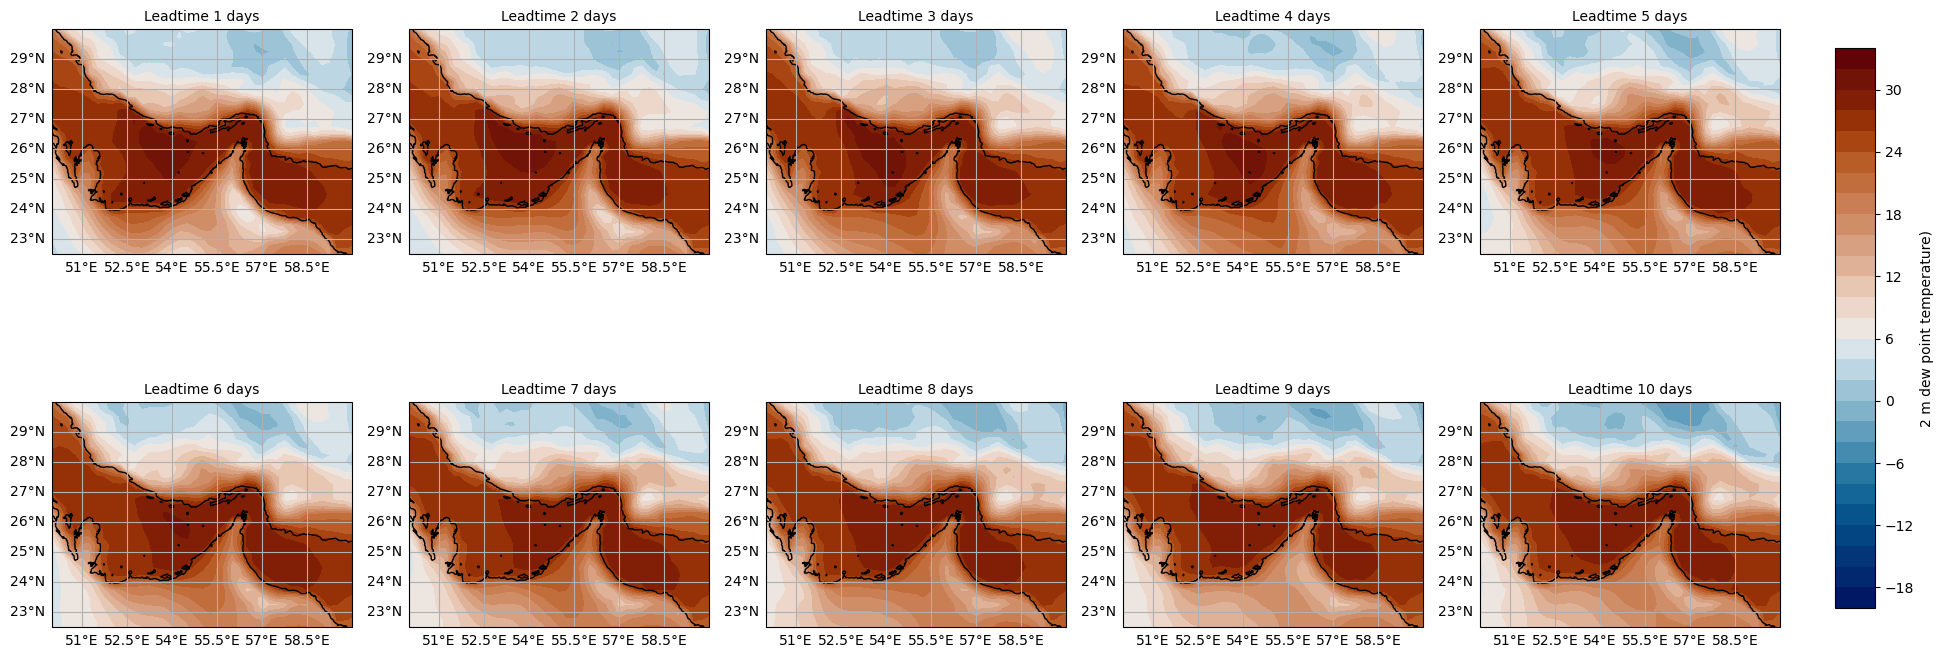

In [6]:
# Ensemble mean
ens_mean = ds_AIFS_sfc.mean(dim="ensemble_members")

# Map projection
map_projection = ccrs.PlateCarree()

# Color levels
V_levels = np.arange(-20, 35, 2)

# Create 2x5 subplot grid
fig, axes = plt.subplots(2, 5, figsize=(20, 8),
                         subplot_kw={'projection': map_projection})
axes = axes.flatten()

for i, lt in enumerate(ens_mean.leadtime.values):
    ax = axes[i]
    
    # Select leadtime
    ds_sel = ens_mean.sel(leadtime=lt)
    
    # Plot wind speed (matplotlib contourf)
    cf = ax.contourf(
        ds_sel.longitude,
        ds_sel.latitude,
        ds_sel['d2m_C'],
        levels=V_levels,
        # cmap='seismic',
        cmap=cm.vik, #colormap here, change it to IPCC
        # vmin=0,
        # vmax=20, #after outcommenting the colors changed
        transform=map_projection
    )
    
    
    # Add coastlines
    ax.add_feature(cfeature.COASTLINE, linestyle='-')
    
    # Add subplot title
    ax.set_title(f'Leadtime {lt} days', fontsize=10)

    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

# Add single shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(cf, cax=cbar_ax, label=r'2 m dew point temperature)')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar



In [7]:
ds_AIFS_sfc.d2m_C.min()

<xarray.DataArray 'd2m_C' ()> Size: 4B
array(-15.391846, dtype=float32)
Coordinates:
    heightAboveGround  float64 8B ...
Attributes: (12/31)
    GRIB_paramId:                             168
    GRIB_dataType:                            pf
    GRIB_numberOfPoints:                      13041
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           2d
    GRIB_totalNumber:                         51
    GRIB_units:                               K
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    standard_name:                            unknown

### AIFS boxplot leadtime evolution before time of interest

when did the AI first time encapture the extreme level?

make a dataset with ensemble members and leadtime but no one spatial dimension, that is define the airports coordinates as the point of interest

26°45′16.70″N 055°54′08.47″E (translated to 26.75 and 56)

In [8]:

AIFS_qeshm=ds_AIFS_sfc.sel(longitude=56, latitude=26.75)

AIFS_qeshm

<xarray.Dataset> Size: 5kB
Dimensions:            (ensemble_members: 50, leadtime: 10)
Coordinates:
    number             (ensemble_members) int64 400B ...
  * leadtime           (leadtime) int64 80B 1 2 3 4 5 6 7 8 9 10
    fc_init_time       (leadtime) datetime64[ns] 80B ...
    fc_valid_time      (leadtime) datetime64[ns] 80B ...
    heightAboveGround  float64 8B ...
    latitude           float64 8B 26.75
    longitude          float64 8B 56.0
Dimensions without coordinates: ensemble_members
Data variables:
    d2m                (ensemble_members, leadtime) float32 2kB 301.5 ... 300.6
    d2m_C              (ensemble_members, leadtime) float32 2kB 28.34 ... 27.43
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T11:08 GRIB to CDM+CF via cfgrib-0.9.1...

In [9]:
#find the ground truth value for the event via ERA5 data at the given coordinates

ERA5_qeshm=ds_ERA5_sfc.sel(longitude=56, latitude=26.75)

ERA5_qeshm

<xarray.Dataset> Size: 64B
Dimensions:     ()
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    latitude    float64 8B 26.75
    longitude   float64 8B 56.0
    valid_time  datetime64[ns] 8B ...
Data variables:
    d2m         float32 4B 300.0
    d2m_C       float32 4B 26.83
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T10:39 GRIB to CDM+CF via cfgrib-0.9.1...

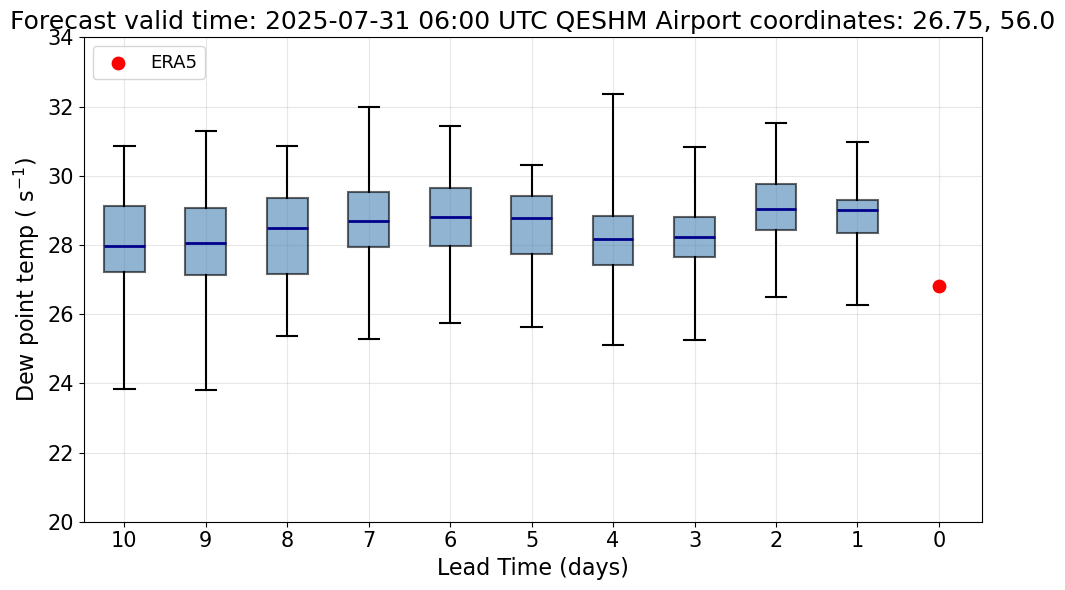

In [10]:
plt.figure(figsize=(10, 6))

leadtimes = np.arange(1, 10+1, 1)
n_leads = len(leadtimes)

# Reverse data so leadtime 10 days appears first #
data_reversed = AIFS_qeshm.d2m_C[:, ::-1]

box = plt.boxplot(
    data_reversed,
    positions=np.arange(1, n_leads + 1),
    whis=[0, 100],
    showfliers=False,
    patch_artist=True,                # allows color filling
    boxprops=dict(facecolor="steelblue", alpha=0.6, linewidth=1.5),
    medianprops=dict(color="darkblue", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)

# ERA5 point
plt.scatter(
    n_leads + 1,
    ERA5_qeshm.d2m_C,
    color="red",
    marker="o",
    s=80,
    zorder=5,
    label="ERA5"
)

# Tick labels
xtick_positions = np.arange(1, n_leads + 2)
xtick_labels = list(leadtimes[::-1]) + [0]

plt.xticks(xtick_positions, xtick_labels, fontsize=15)
plt.yticks(fontsize=15)

# valid_time = pd.to_datetime(ds_AIFS.fc_valid_time.values[0])
# time_str = valid_time.strftime("%Y-%m-%d %H:%M")

plt.title("Forecast valid time: 2025-07-31 06:00 UTC QESHM Airport coordinates: 26.75, 56.0", fontsize=18)

plt.xlabel("Lead Time (days)", fontsize=16)
plt.ylabel("Dew point temp ( s$^{-1}$)", fontsize=16)
plt.yticks(np.arange(20,33+2,2))

plt.legend(fontsize=13,loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Leadtime boxplot value where the location is the max value from the ERA5 dataset

latlon defined after max dm2 in the ERA5 in the subset region. This can be over the ocean.

# ERA 5 maps 

Here I produce ERA5 map of the subset region

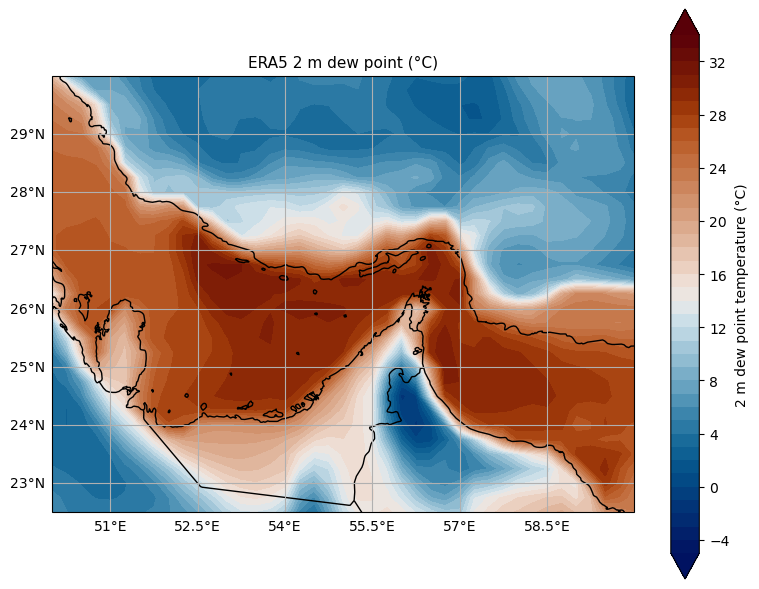

In [12]:
# ERA5: usually no ensemble_members/leadtime dimensions
map_projection = ccrs.PlateCarree()

# Start from dew point in degC and reduce any singleton extra dims
era5_plot = ds_ERA5_sfc["d2m_C"]
for dim in ["valid_time", "time", "step", "leadtime", "ensemble_members", "number"]:
    if dim in era5_plot.dims:
        era5_plot = era5_plot.isel({dim: 0})

V_levels = np.arange(-5, 35, 1)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), subplot_kw={"projection": map_projection})

cf = ax.contourf(
    era5_plot.longitude,
    era5_plot.latitude,
    era5_plot,
    levels=V_levels,
    cmap=cm.vik,
    transform=map_projection,
    extend="both"
)

ax.add_feature(cfeature.COASTLINE, linestyle='-')
ax.add_feature(cfeature.BORDERS)
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

ax.set_title("ERA5 2 m dew point (°C)", fontsize=11)
fig.colorbar(cf, ax=ax, label="2 m dew point temperature (°C)")
plt.tight_layout()

# Bias check between ERA5 and AIFS

In [18]:
print("leadtime values:", ens_mean.leadtime.values)


leadtime values: [ 1  2  3  4  5  6  7  8  9 10]


In [28]:
ds_AIFS_sfc

#we need one ensemble average - dataset already created
ens_mean

#but now I have 10 leadtime - leadtime 1 is closest to the event

ens_mean_event=ens_mean.sel(leadtime=1)

ens_mean_event


<xarray.Dataset> Size: 11kB
Dimensions:            (latitude: 31, longitude: 41)
Coordinates:
  * latitude           (latitude) float64 248B 30.0 29.75 29.5 ... 22.75 22.5
  * longitude          (longitude) float64 328B 50.0 50.25 50.5 ... 59.75 60.0
    fc_init_time       datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    fc_valid_time      datetime64[ns] 8B ...
    leadtime           int64 8B 1
Data variables:
    d2m                (latitude, longitude) float32 5kB 292.8 284.5 ... 296.6
    d2m_C              (latitude, longitude) float32 5kB 19.68 11.37 ... 23.46
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T11:08 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
print(ens_mean_event.fc_valid_time.values) #do not change the time when I change leadtime...
print("coords:", list(ds_AIFS_sfc.coords))

2025-07-31T06:00:00.000000000
coords: ['number', 'fc_init_time', 'heightAboveGround', 'latitude', 'longitude', 'fc_valid_time', 'leadtime']


In [14]:
ds_ERA5_sfc

<xarray.Dataset> Size: 11kB
Dimensions:     (latitude: 31, longitude: 41)
Coordinates:
  * latitude    (latitude) float64 248B 30.0 29.75 29.5 ... 23.0 22.75 22.5
  * longitude   (longitude) float64 328B 50.0 50.25 50.5 ... 59.5 59.75 60.0
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Data variables:
    d2m         (latitude, longitude) float32 5kB 290.8 283.7 ... 295.3 296.1
    d2m_C       (latitude, longitude) float32 5kB 17.62 10.52 ... 22.14 22.97
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-17T10:39 GRIB to CDM+CF via cfgrib-0.9.1...

## Bias evaluation

Here AIFS leadtime 1 is subtracted ERA5.
NB need to verify the time AIFS corresponds to

The lat long are from the same subset and the dimensions now fit. Ensemble mean is used for AIFS

In [40]:
bias=ds_ERA5_sfc.d2m_C-ens_mean_event.d2m_C

print(bias.values)

print(bias.to_dataframe(name="df_bias").reset_index())

[[-2.0665035  -0.8554497  -1.0723829  ...  2.0808203   1.4666796
   2.100078  ]
 [ 0.12623215 -0.21863365 -0.8379097  ...  2.2645702   1.5130274
   2.9061522 ]
 [ 0.1168766  -0.01767921 -0.14476395 ...  2.3093555   2.005625
   3.1092188 ]
 ...
 [ 0.6027541  -0.30062485 -1.4932423  ...  3.1318169   1.7357235
  -0.4074211 ]
 [ 1.5223243   0.4893751  -0.7307224  ...  1.2426968   0.50123215
  -0.68224525]
 [ 1.7900586   0.9725585   0.30121088 ...  1.0753899  -0.1594963
  -0.4898224 ]]
      latitude  longitude  number                time   step  surface  \
0         30.0      50.00       0 2025-07-31 06:00:00 0 days      0.0   
1         30.0      50.25       0 2025-07-31 06:00:00 0 days      0.0   
2         30.0      50.50       0 2025-07-31 06:00:00 0 days      0.0   
3         30.0      50.75       0 2025-07-31 06:00:00 0 days      0.0   
4         30.0      51.00       0 2025-07-31 06:00:00 0 days      0.0   
...        ...        ...     ...                 ...    ...      ...   
126

In [49]:
#print(f'max bias {bias.max()} and min bias {bias.min()}')

bias.max()

<xarray.DataArray 'd2m_C' ()> Size: 4B
array(4.345215, dtype=float32)
Coordinates:
    number             int64 8B ...
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    surface            float64 8B ...
    valid_time         datetime64[ns] 8B ...
    fc_init_time       datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    fc_valid_time      datetime64[ns] 8B 2025-07-31T06:00:00
    leadtime           int64 8B 1
Attributes: (12/27)
    GRIB_paramId:                             168
    GRIB_numberOfPoints:                      13041
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    GRIB_uvRelativeToGrid:                    0
    ...                                       ...
    GRIB_name:                                2 metre dewpoint temperature
    GRIB_shortName:                           2d
    GRIB_units:                               K
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    standard_name:                            unknown

In [50]:
bias.min()

<xarray.DataArray 'd2m_C' ()> Size: 4B
array(-10.669082, dtype=float32)
Coordinates:
    number             int64 8B ...
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    surface            float64 8B ...
    valid_time         datetime64[ns] 8B ...
    fc_init_time       datetime64[ns] 8B ...
    heightAboveGround  float64 8B ...
    fc_valid_time      datetime64[ns] 8B 2025-07-31T06:00:00
    leadtime           int64 8B 1
Attributes: (12/27)
    GRIB_paramId:                             168
    GRIB_numberOfPoints:                      13041
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    GRIB_uvRelativeToGrid:                    0
    ...                                       ...
    GRIB_name:                                2 metre dewpoint temperature
    GRIB_shortName:                           2d
    GRIB_units:                               K
    long_name:                                2 metre dewpoint temperature
    units:                                    K
    standard_name:                            unknown

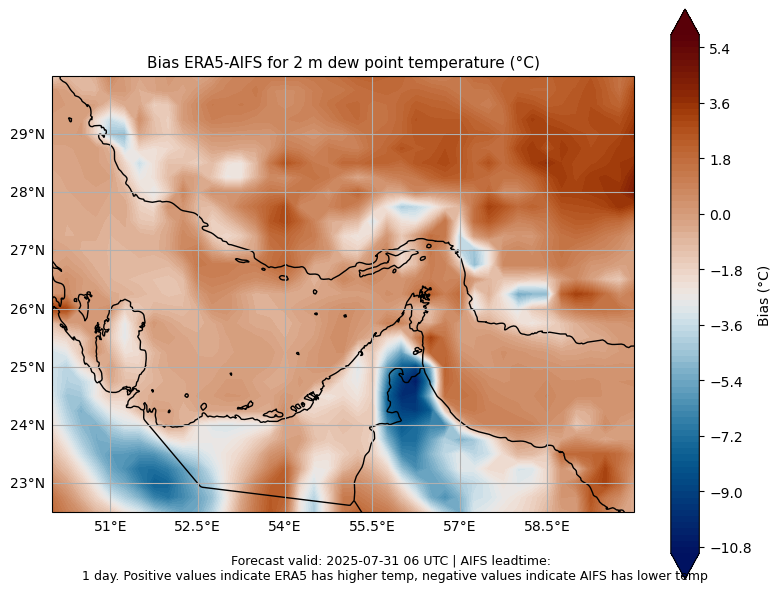

In [57]:
#map of the bias

map_projection = ccrs.PlateCarree()

# Start from dew point in degC and reduce any singleton extra dims
bias_plot = bias
for dim in ["valid_time", "time", "step", "leadtime", "ensemble_members", "number"]:
    if dim in bias_plot.dims:
        bias_plot = bias_plot.isel({dim: 0})

V_levels = np.arange(-11, 6, 0.2)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), subplot_kw={"projection": map_projection})

cf = ax.contourf(
    bias_plot.longitude,
    bias_plot.latitude,
    bias_plot,
    levels=V_levels,
    cmap=cm.vik,
    transform=map_projection,
    extend="both"
)

ax.add_feature(cfeature.COASTLINE, linestyle='-')
ax.add_feature(cfeature.BORDERS)
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

ax.set_title("Bias ERA5-AIFS for 2 m dew point temperature (°C)", fontsize=11)
fig.colorbar(cf, ax=ax, label="Bias (°C)")

fig.text(
    0.5, 0.02,
    "Forecast valid: 2025-07-31 06 UTC | AIFS leadtime:  \n"
    "1 day. Positive values indicate ERA5 has higher temp, negative values indicate AIFS has lower temp",
    ha="center", va="bottom", fontsize=9
)

plt.tight_layout(rect=[0, 0.06, 1, 1])  # leave space at bottom for fig.text
plt.tight_layout()